## Loading

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
GTE_DIR=os.environ["GTE_DIR"]
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.Helper_fun import float_range
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import cmcrameri.cm

In [2]:
# import sys
# !{sys.executable} -m pip install pycairo

Setup matplotlib


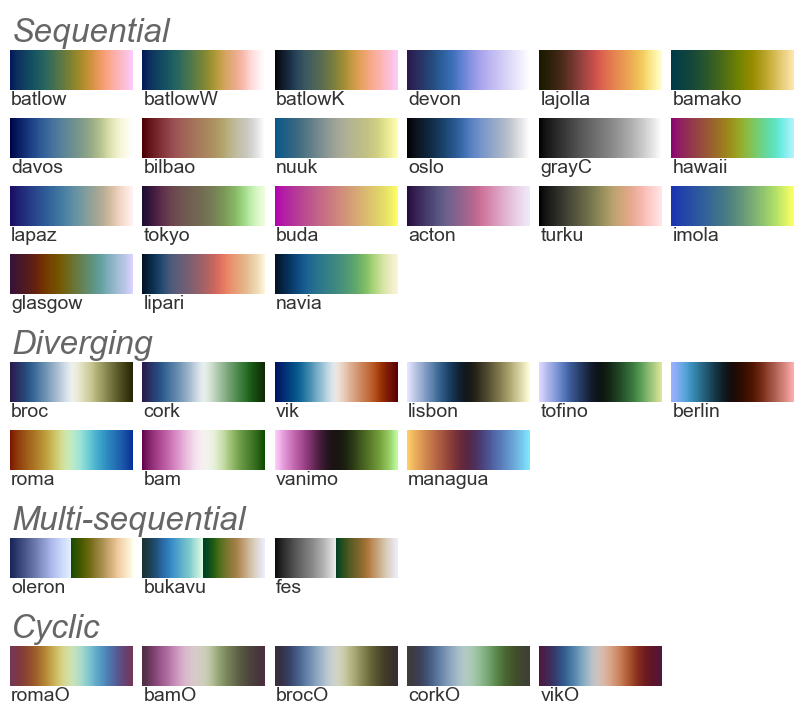

In [3]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":6})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()

Set parameters

In [4]:
config = read_config(
    os.path.join('/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/config_n2o.yaml'))
analyze_year=True
# years=[2007,2008,2009,2010,2011,2012,2013,2014,2015]
years = [year for year in range(2007, 2016)]
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
# classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# classifiacation_palette = ['#00429d', '#93003a','#ffffe0']
classifiacation_palette = cmcrameri.cm.actonS.colors[[i for i in range(10) if i != 1],:]
temperature_palette = ["#0d0d0f",'#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
default_colormap=cmcrameri.cm.acton


Load data

In [5]:
temp_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","temp_occurance_rate.csv"))
pole_temp_or =pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_occurance_rate.csv"))
pole_temp_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_occurance_rate_glac_possible.csv"))
pole_temp_season_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_season_occurance_rate.csv"))
pole_temp_season_or_glac_possible = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","pole_temp_season_occurance_rate_glac_possible.csv"))
glac_thresh_or = pd.read_csv(os.path.join(GTE_DIR, "Result_analysis","Multiyear_analysis","glac_thresh_occurance_rates.csv"))
# temp_or["Occurance rate"] *= 100
pole_temp_or["Occurance rate"] *= 100
pole_temp_or_glac_possible['Occurance rate']*= 100
pole_temp_season_or["Occurance rate"] *= 100
pole_temp_season_or_glac_possible['Occurance rate']*= 100

## Publication Figures

In [48]:
mpl.use('cairo')

In [49]:
small_ax_range=(0,15)
large_ax_range=(-2.5,12.5)
var_thresh_ax_range=(0,35)
small_major_ticks=np.linspace(small_ax_range[0],small_ax_range[1],4)
small_minor_ticks=np.arange(small_ax_range[0],small_ax_range[1],0.5)
large_major_ticks=list(np.linspace(large_ax_range[0],large_ax_range[1],7))
# large_major_ticks.append(0.0)
large_minor_ticks=np.arange(large_ax_range[0],large_ax_range[1],0.5)
var_thresh_major_ticks=np.linspace(var_thresh_ax_range[0],var_thresh_ax_range[1],8)
var_thresh_minor_ticks=np.arange(var_thresh_ax_range[0],var_thresh_ax_range[1],1)
large_major_ticks
large_minor_ticks

array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,
        3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,  7.5,  8. ,
        8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. ])

Left side

In [50]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3.504), constrained_layout=True)
gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)

ax1.set_xticks(x)
ax1.set_yticks(large_major_ticks)
ax1.set_yticks(large_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)
temp_handles, temp_labels = ax1.get_legend_handles_labels()
order = [0,2,1]
ax1.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[1, :])


# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02


ax2.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax2.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax2.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax2.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax2.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax2.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax2.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)


ax2
ax2.set_xticks(x)
ax2.set_yticks(large_major_ticks)
ax2.set_yticks(large_minor_ticks,minor=True)

ax2.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax2.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax2.legend(fontsize=5)
ax2.set_xlim(5.2, -0.2)
ax2.set_ylim(large_ax_range)
temp_handles, temp_labels = ax2.get_legend_handles_labels()
order = [0,2,1]
ax2.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
ax1.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_left.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

Right side

In [52]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or_glac_possible.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3.504), constrained_layout=True)
gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[1, :])

glac_thresh_list=glac_thresh_or["threshold"].unique()
var_glac_thresh_cm = default_colormap(np.linspace(0, 0.7, len(glac_thresh_list)))[::-1]
for glac_i, glac_threshold in enumerate(glac_thresh_list):
    temp_y=glac_thresh_or.groupby(["threshold","min_temp"])['occurance_rate'].mean()[glac_threshold]
    # ax1.plot(x,temp_y , marker='s', label=f'Glac Thresh: {glac_threshold}', color=var_glac_thresh_cm[glac_i],
    #       linewidth=1,markersize=2)
    ax1.plot(x,temp_y , marker='o', label=f'Glac Thresh: {glac_threshold}', color=var_glac_thresh_cm[glac_i],
          linewidth=1,markersize=2)
    temp_std= glac_thresh_or.groupby(["threshold","min_temp"])['occurance_rate'].std()[glac_threshold]
    ax1.fill_between(
        x,
        temp_y - temp_std,
        temp_y + temp_std, alpha=0.3,edgecolor="none",color=var_glac_thresh_cm[glac_i]
    )
# # Fill‐between for error bands
# ax1.fill_between(
#     x,
#     north_over['mean'] - north_over['std'],
#     north_over['mean'] + north_over['std'],
#     color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
# )
# ax1.fill_between(
#     x,
#     south_over['mean'] - south_over['std'],
#     south_over['mean'] + south_over['std'],
#     color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
# )
# ax1.fill_between(
#     x,
#     diff_mean - diff_std,
#     diff_mean + diff_std,
#     color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
# )

ax1.set_xticks(x)
ax1.set_yticks(var_thresh_major_ticks)
ax1.set_yticks(var_thresh_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(var_thresh_ax_range)
ax1.legend()

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[0, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0],linewidth=1,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1],linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2,edgecolor='none'
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2,edgecolor='none'
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("Summer (JJA) & Winter (DJF)",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Bottom right: MAM & SON ---
ax3 = fig.add_subplot(gs[0, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0], linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1], linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2,edgecolor='none'
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2,edgecolor='none'
    )
# ax1.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("Spring (MAM) & Fall (SON)",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
ax1.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
ax3.spines[['right', 'top']].set_visible(False)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_right.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

# Draft versions

### Overall + Season Layout 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or_glac_possible and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3))
gs = gridspec.GridSpec(2, 2, hspace=1.2, wspace=0.3)#height_ratios=[1, 1]

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3
)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title(f"Occurrence Rate of Glaciation by Temperature Bin\n"
#     r"in Non-Glaciated Clouds ($\mathregular{{IF_{{min}}}}<0.6$) "
#     f"for the period {min(years)} to {max(years)}",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)


ax1.set_yticks(large_minor_ticks,minor=True)
# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[1, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0],linewidth=1, alpha=0.7,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1],linewidth=1, alpha=0.7,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("Seasonal Occurrence Rates:\nSummer (JJA) & Winter (DJF)",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Bottom right: MAM & SON ---
ax3 = fig.add_subplot(gs[1, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7, linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7, linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2
    )
# ax1.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("Seasonal Occurrence Rates:\nSpring (MAM) & Fall (SON)",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)


plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Multiyear_analysis/Occurance_rates_glac_possible.pdf",dpi=300)#, bbox_inches = "tight")
plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Occurance_rates_right.pdf",dpi=300)#, bbox_inches = "tight")
print(fig.get_size_inches)
# plt.close()

<bound method Figure.get_size_inches of <Figure size 350.4x300 with 3 Axes>>


In [57]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
# sns.set_style("darkgrid")
sns.set_style("white")
# sns.despine()  # removes top/right spines and also disables bottom/left tick positions

# Assuming pole_temp_or and pole_temp_season_or are already loaded,
# as well as classifiacation_palette and GTE_DIR.

# 1. Compute overall occurrence rates (mean and std across years)
overall = pole_temp_or.groupby(['min_temp', 'Hemisphere'])['Occurance rate'] \
                      .agg(['mean', 'std']).reset_index()
# Pivot for easier access
north_over = overall[overall['Hemisphere'] == 'North'].set_index('min_temp')
south_over = overall[overall['Hemisphere'] == 'South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere, each season
seasonal = pole_temp_season_or.groupby(['Season', 'min_temp', 'Hemisphere'])['Occurance rate'] \
                              .agg(['mean', 'std']).reset_index()
# Helper to extract series
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season'] == season) & (seasonal['Hemisphere'] == hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

# Seasons to plot
seasons = ['JJA', 'DJF', 'MAM', 'SON']
seas_pairs = [('JJA', 'DJF'), ('MAM', 'SON')]

# Bin labels
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]

# X positions
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 3. Create figure with GridSpec
fig = plt.figure(figsize=(3.504, 3.5), constrained_layout=True)
gs = gridspec.GridSpec(2, 2,height_ratios=[1, 1],figure=fig)#,hspace=1.2, wspace=0.3)#,

# --- Top subplot: overall ---
ax1 = fig.add_subplot(gs[0, :])
ax1.axhline(0, color="black", linestyle="--", linewidth=0.5)

# Plot mean lines
ax1.plot(x, north_over['mean'], marker='v', label='North',
         color=classifiacation_palette[0], linewidth=1,markersize=2)

# Difference
diff_mean = north_over['mean'] - south_over['mean']
diff_std = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=1,markersize=2)
ax1.plot(x, south_over['mean'], marker='s', label='South',
         color=classifiacation_palette[1], linewidth=1,markersize=2)

# Fill‐between for error bands
ax1.fill_between(
    x,
    north_over['mean'] - north_over['std'],
    north_over['mean'] + north_over['std'],
    color=classifiacation_palette[0], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    south_over['mean'] - south_over['std'],
    south_over['mean'] + south_over['std'],
    color=classifiacation_palette[1], alpha=0.3,edgecolor="none"
)
ax1.fill_between(
    x,
    diff_mean - diff_std,
    diff_mean + diff_std,
    color=classifiacation_palette[2], alpha=0.3,edgecolor="none"
)

ax1.set_xticks(x)
ax1.set_yticks(large_major_ticks)
ax1.set_yticks(large_minor_ticks,minor=True)

ax1.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)
ax1.invert_xaxis()
ax1.set_xlabel("Temperature Bin Range",fontsize=6)
ax1.set_ylabel("Occurrence Rate [%]",fontsize=6)
# ax1.set_title("Overall Occurrence Rate of Glaciation by Hemisphere",fontsize=7)
ax1.legend(fontsize=5)
ax1.set_xlim(5.2, -0.2)
ax1.set_ylim(large_ax_range)
temp_handles, temp_labels = ax1.get_legend_handles_labels()
order = [0,2,1]
ax1.legend([temp_handles[idx] for idx in order],[temp_labels[idx] for idx in order])

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax1.xaxis.set_ticks_position('bottom')
ax1.yaxis.set_ticks_position('left')
ax1.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=1, direction='out',labelsize=5
)
ax1.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.7, direction='out'
)
ax1.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=1, direction='out',labelsize=5
)



# --- Bottom left: JJA & DJF ---
ax2 = fig.add_subplot(gs[1, 0])
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0],linewidth=1,markersize=1.5)
    ax2.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1],linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[0], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax2.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0], alpha=0.2,edgecolor='none'
    )
    ax2.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1], alpha=0.2,edgecolor='none'
    )

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=5)
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range",fontsize=6)
ax2.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax2.set_title("Summer (JJA) & Winter (DJF)",fontsize=6)
ax2.legend(loc='upper left',fontsize=5)

# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax2.xaxis.set_ticks_position('bottom')
ax2.yaxis.set_ticks_position('left')
ax2.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax2.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax2.set_yticks(small_minor_ticks, minor=True)
ax2.set_ylim(small_ax_range)

# --- Bottom right: MAM & SON ---
ax3 = fig.add_subplot(gs[1, 1])
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    ax3.plot(x, mn_n, linestyle=style, marker='v',
             label=f"North {season}", color=classifiacation_palette[0], linewidth=1,markersize=1.5)
    ax3.plot(x, mn_s, linestyle=style, marker='s',
             label=f"South {season}", color=classifiacation_palette[1], linewidth=1,markersize=1.5)

# Fill‐between for error bands
for season, style in zip(seas_pairs[1], ['--', ':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')
    # North band
    ax3.fill_between(
        x,
        mn_n - sd_n,
        mn_n + sd_n,
        color=classifiacation_palette[0],
        alpha=0.2,edgecolor='none'
    )
    # South band
    ax3.fill_between(
        x,
        mn_s - sd_s,
        mn_s + sd_s,
        color=classifiacation_palette[1],
        alpha=0.2,edgecolor='none'
    )
# ax1.tick_params(minor=True)           # thickness of the tick‐lines
# <<< RE‐ENABLE TICK LINES ON BOTTOM/LEFT >>>
ax3.xaxis.set_ticks_position('bottom')
ax3.yaxis.set_ticks_position('left')
ax3.tick_params(
    axis='x', which='both',
    bottom=True, top=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.tick_params(
    axis='y', which='minor',
    bottom=True, top=False,
    length=1.2, width=0.5, direction='out'
)
ax3.tick_params(
    axis='y', which='major',
    left=True, right=False,
    length=2, width=0.7, direction='out',labelsize=5
)
ax3.set_yticks(small_minor_ticks, minor=True)
ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right',fontsize=5)

ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range",fontsize=6)
ax3.set_ylabel("Occurrence Rate [%]",fontsize=6)
ax3.set_title("Spring (MAM) & Fall (SON)",fontsize=6)
ax3.legend(loc='upper left',fontsize=5)
ax3.set_ylim(small_ax_range)
# plt.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Multiyear_analysis/Occurance_rates.pdf",dpi=300, bbox_inches = "tight")
# plt.close()
# fig = plt.figure(figsize=(3.504, 3))
# … all your plotting code …

# Option A: remove bbox_inches
# fig.tight_layout(pad=0.1)
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Multiyear_analysis/Occurance_rates.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

In [90]:
plt.close()

## Old Figure Versions

In [41]:
# assume your DataFrame is called df

# 1-st.norm.cdf(diff_df.groupby('min_temp')['diff'].mean() / diff_df.groupby('min_temp')['diff'].std())


In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import scipy.stats as st
# 1. Pivot so that each (year, min_temp) has North and South in separate columns
pivot = pole_temp_or_glac_possible.pivot(index=['year', 'min_temp'],
                 columns='Hemisphere',
                 values='Occurance rate')
# print(pivot)
# 2. Compute the difference (North minus South)
pivot['diff'] = pivot['North'] - pivot['South']

# 3. (Optional) Bring it back to a flat DataFrame
diff_df = pivot['diff'].reset_index()


# Assuming the following are already defined:
# pole_temp_or_glac_possible, pole_temp_season_or_glac_possible,
# classifiacation_palette, years

# 1. Compute overall occurrence rates (mean and std across years)
overall = (
    pole_temp_or_glac_possible
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .agg(['mean', 'std'])
    .reset_index()
)
north_over = overall[overall['Hemisphere']=='North'].set_index('min_temp')
south_over = overall[overall['Hemisphere']=='South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere & season
seasonal = (
    pole_temp_season_or_glac_possible
    .groupby(['Season','min_temp','Hemisphere'])['Occurance rate']
    .agg(['mean','std'])
    .reset_index()
)
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season']==season)&(seasonal['Hemisphere']==hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

seas_pairs = [('JJA','DJF'), ('MAM','SON')]

# 3. Prepare x-axis bins
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 4. Create figure
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2,2, height_ratios=[1,1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(x, north_over['mean'], marker='o', label='North',
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South',
         color=classifiacation_palette[1], linewidth=2)

diff_mean = north_over['mean'] - south_over['mean']
diff_std  = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=2)

# Replace errorbars with filled error bands
ax1.fill_between(x,
                 north_over['mean'] - north_over['std'],
                 north_over['mean'] + north_over['std'],
                 color=classifiacation_palette[0], alpha=0.3)
ax1.fill_between(x,
                 south_over['mean'] - south_over['std'],
                 south_over['mean'] + south_over['std'],
                 color=classifiacation_palette[1], alpha=0.3)
ax1.fill_between(x,
                 diff_df.groupby('min_temp')['diff'].mean() - diff_df.groupby('min_temp')['diff'].std(),
                 diff_df.groupby('min_temp')['diff'].mean() + diff_df.groupby('min_temp')['diff'].std(),
                 color=classifiacation_palette[2], alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title(
    f"Occurrence Rate of Glaciation by Temperature Bin\n"
    r"in Non-Glaciated Clouds ($\mathregular{{IF_{{min}}}}<0.6$) "
    f"for the period {min(years)} to {max(years)}",
    fontsize=16, pad=15, fontweight="bold"
)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.legend(title="Hemisphere")

# Bottom-left: JJA & DJF
ax2 = fig.add_subplot(gs[1,0])
for season, style in zip(seas_pairs[0], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax2.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax2.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax2.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\nfor Summer (JJA) & Winter (DJF)",
              fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.legend(title="Hemisphere & Season", loc="upper left")

# Bottom-right: MAM & SON
ax3 = fig.add_subplot(gs[1,1])
for season, style in zip(seas_pairs[1], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax3.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax3.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax3.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)",
              fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.legend(title="Hemisphere & Season", loc="upper left")

# --- Top: overall ---
# ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-left: JJA & DJF ---
# ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-right: MAM & SON ---
# ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.xaxis.grid(False)    # ← turn off vertical grid


plt.tight_layout()
plt.savefig(f"{GTE_DIR}/Result_graphs/Multiyear_analysis/Seasonal_occ_rates_non_glac.png", dpi=300)
# plt.show()


NameError: name 'pole_temp_or_glac_possible' is not defined

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

import scipy.stats as st
# 1. Pivot so that each (year, min_temp) has North and South in separate columns
pivot = pole_temp_or.pivot(index=['year', 'min_temp'],
                 columns='Hemisphere',
                 values='Occurance rate')
print(pivot)
# 2. Compute the difference (North minus South)
pivot['diff'] = pivot['North'] - pivot['South']

# 3. (Optional) Bring it back to a flat DataFrame
diff_df = pivot['diff'].reset_index()


# Assuming the following are already defined:
# pole_temp_or_glac_possible, pole_temp_season_or_glac_possible,
# classifiacation_palette, years

# 1. Compute overall occurrence rates (mean and std across years)
overall = (
    pole_temp_or
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .agg(['mean', 'std'])
    .reset_index()
)
north_over = overall[overall['Hemisphere']=='North'].set_index('min_temp')
south_over = overall[overall['Hemisphere']=='South'].set_index('min_temp')

# 2. Compute seasonal occurrence rates for each hemisphere & season
seasonal = (
    pole_temp_season_or
    .groupby(['Season','min_temp','Hemisphere'])['Occurance rate']
    .agg(['mean','std'])
    .reset_index()
)
def get_season_data(season, hemi):
    df = seasonal[(seasonal['Season']==season)&(seasonal['Hemisphere']==hemi)]
    df = df.set_index('min_temp').reindex(north_over.index).fillna(0)
    return df['mean'], df['std']

seas_pairs = [('JJA','DJF'), ('MAM','SON')]

# 3. Prepare x-axis bins
bin_temps = north_over.index.tolist()
bin_labels = [f"{int(t)} to {int(t+6)} °C" for t in bin_temps]
x = np.arange(len(bin_temps))
x_north = x + 0.02
x_south = x - 0.02

# 4. Create figure
fig = plt.figure(figsize=(14,12))
gs = gridspec.GridSpec(2,2, height_ratios=[1,1], hspace=0.4, wspace=0.3)

# Top: overall
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(x, north_over['mean'], marker='o', label='North',
         color=classifiacation_palette[0], linewidth=2)
ax1.plot(x, south_over['mean'], marker='o', label='South',
         color=classifiacation_palette[1], linewidth=2)

diff_mean = north_over['mean'] - south_over['mean']
diff_std  = np.sqrt(north_over['std']**2 + south_over['std']**2)
ax1.plot(x, diff_mean, marker='o', label='Difference',
         color=classifiacation_palette[2], linewidth=2)

# Replace errorbars with filled error bands
ax1.fill_between(x,
                 north_over['mean'] - north_over['std'],
                 north_over['mean'] + north_over['std'],
                 color=classifiacation_palette[0], alpha=0.3)
ax1.fill_between(x,
                 south_over['mean'] - south_over['std'],
                 south_over['mean'] + south_over['std'],
                 color=classifiacation_palette[1], alpha=0.3)
ax1.fill_between(x,
                 diff_df.groupby('min_temp')['diff'].mean() - diff_df.groupby('min_temp')['diff'].std(),
                 diff_df.groupby('min_temp')['diff'].mean() + diff_df.groupby('min_temp')['diff'].std(),
                 color=classifiacation_palette[2], alpha=0.3)

ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
ax1.invert_xaxis()
ax1.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax1.set_title(
    f"Occurrence Rate of Glaciation by Temperature Bin\n"
    f"for the period {min(years)} to {max(years)}",
    fontsize=16, pad=15, fontweight="bold"
)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', labelsize=12, rotation=45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim(-5, 20)
ax1.legend(title="Hemisphere")

# Bottom-left: JJA & DJF
ax2 = fig.add_subplot(gs[1,0])
for season, style in zip(seas_pairs[0], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax2.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax2.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax2.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax2.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels, rotation=45, ha='right')
ax2.invert_xaxis()
ax2.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax2.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax2.set_title("Seasonal Occurrence Rates\nfor Summer (JJA) & Winter (DJF)",
              fontsize=16, pad=15)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', labelsize=12, rotation=45)
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylim(0, 25)
ax2.legend(title="Hemisphere & Season", loc="upper left")

# Bottom-right: MAM & SON
ax3 = fig.add_subplot(gs[1,1])
for season, style in zip(seas_pairs[1], ['--',':']):
    mn_n, sd_n = get_season_data(season, 'North')
    mn_s, sd_s = get_season_data(season, 'South')

    ax3.plot(x, mn_n, linestyle=style, marker='o',
             label=f"North {season}", color=classifiacation_palette[0], alpha=0.7)
    ax3.plot(x, mn_s, linestyle=style, marker='o',
             label=f"South {season}", color=classifiacation_palette[1], alpha=0.7)

    ax3.fill_between(x,
                     mn_n - sd_n,
                     mn_n + sd_n,
                     color=classifiacation_palette[0], alpha=0.2)
    ax3.fill_between(x,
                     mn_s - sd_s,
                     mn_s + sd_s,
                     color=classifiacation_palette[1], alpha=0.2)

ax3.set_xticks(x)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.invert_xaxis()
ax3.set_xlabel("Temperature Bin Range", fontsize=14, labelpad=10)
ax3.set_ylabel("Occurrence Rate [%]", fontsize=14, labelpad=10)
ax3.set_title("Seasonal Occurrence Rates\nfor Spring (MAM) & Fall (SON)",
              fontsize=16, pad=15)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.tick_params(axis='x', labelsize=12, rotation=45)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 25)
ax3.legend(title="Hemisphere & Season", loc="upper left")

# --- Top: overall ---
# ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-left: JJA & DJF ---
# ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.xaxis.grid(False)    # ← turn off vertical grid

# --- Bottom-right: MAM & SON ---
# ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.xaxis.grid(False)    # ← turn off vertical grid


plt.tight_layout()
plt.savefig(f"{GTE_DIR}/Result_graphs/Multiyear_analysis/Seasonal_occ_rates.png", dpi=300)
# plt.show()


Hemisphere         North      South
year min_temp                      
2007 -36        9.902444  10.785365
     -30        7.220691   5.427187
     -24        4.449587   2.823052
     -18        2.484720   1.813936
     -12        0.743626   0.580076
     -6         0.000000   0.000000
2008 -36        9.528375  10.810230
     -30        7.402934   5.357355
     -24        4.596888   2.766976
     -18        2.529138   1.799918
     -12        0.679957   0.596806
     -6         0.000000   0.000000
2009 -36        9.456826  10.541389
     -30        6.938630   5.095891
     -24        4.315120   2.669252
     -18        2.462080   1.738531
     -12        0.717297   0.564812
     -6         0.000000   0.000000
2010 -36        9.611457  11.268241
     -30        7.259360   5.735749
     -24        4.600676   2.970935
     -18        2.731036   1.936465
     -12        0.771413   0.613566
     -6         0.000000   0.000000
2011 -36        9.579088  11.235743
     -30        7.834016   6

/tmp/ipykernel_21122/991684146.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


## Figure testing

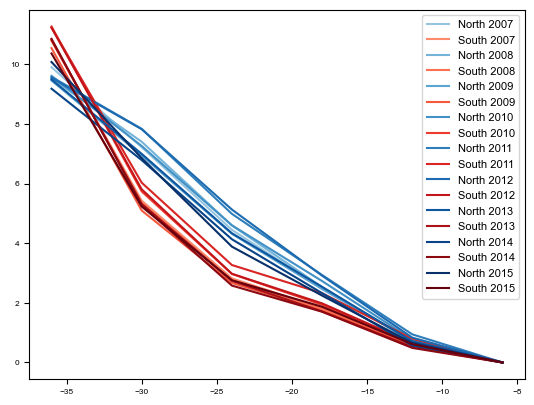

In [8]:
i=0
groups = pole_temp_or.groupby(["year","Hemisphere"])
n_groups = round(len(groups)/2)
# Generate two palettes from the Reds and Blues colormaps:
temperature_palette_north = plt.cm.Blues(np.linspace(0.4, 1, n_groups))
temperature_palette_south =  plt.cm.Reds(np.linspace(0.4, 1, n_groups))
for list in groups:
    Hemisphere= list[0][1]
    # print(Hemisphere)
    if Hemisphere == "North":
        plt.plot(list[1]["min_temp"], list[1]["Occurance rate"], color=temperature_palette_north[int(i/2)], label=f"{Hemisphere} {int(2007+int(i)/2)}")
    if Hemisphere == "South":
        plt.plot(list[1]["min_temp"], list[1]["Occurance rate"], color=temperature_palette_south[int(i/2)], label=f"{Hemisphere} {int(2007+int(i)/2)}")
    i+=1
plt.legend(loc='upper right', fontsize=8)
    

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# First, determine how many distinct (year, Hemisphere) groups you have:
groups = pole_temp_or.groupby(["year", "Hemisphere"])
n_groups = len(groups)

# # Generate two palettes from the Reds and Blues colormaps:
# temperature_palette_north = plt.cm.Reds(np.linspace(0.4, 1, n_groups))
# temperature_palette_south = plt.cm.Blues(np.linspace(0.4, 1, n_groups))

# # Now plot, pulling colors from those palettes in order:
# i = 0
# for (year, hemi), df_grp in groups:
#     if hemi == "North":
#         plt.plot(df_grp["min_temp"],
#                  df_grp["Occurance rate"],
#                  color=temperature_palette_north[i],
#                  label=f"{hemi} {year}")
#     elif hemi == "South":          # fixed typo from "Sounth" → "South"
#         plt.plot(df_grp["min_temp"],
#                  df_grp["Occurance rate"],
#                  color=temperature_palette_south[i],
#                  label=f"{hemi} {year}")
#     i += 1

# plt.xlabel("Minimum Temperature")
# plt.ylabel("Occurrence Rate")
# plt.legend(ncol=2, fontsize="small")
# plt.show()


In [10]:
or_list = -temp_or[temp_or['min_temp']==-24].values[0,1:]
or_list

array([-3.53718304, -3.64714438, -3.45052857, -3.72833853, -4.06273601,
       -3.98564364, -3.44686595, -3.2910717 , -3.27911727])

In [11]:
import pymannkendall as pkm

In [12]:
pkm.pre_whitening_modification_test(or_list, alpha=0.05)

Modified_Mann_Kendall_Test_PreWhitening_Approach(trend='no trend', h=False, p=0.38647623077123283, z=0.8660254037844386, Tau=0.2857142857142857, s=8.0, var_s=65.33333333333333, slope=0.033708491310959585, intercept=-3.672017003811918)

In [13]:
temp_or[pole_temp_or["Hemisphere"]=="North"]

/tmp/ipykernel_21122/71120718.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp_or[pole_temp_or["Hemisphere"]=="North"]


,min_temp,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,-36,10.483330,10.342348,10.121308,10.648339,10.623724,10.609363,10.357735,10.280185,10.256327
2,-24,3.537183,3.647144,3.450529,3.728339,4.062736,3.985644,3.446866,3.291072,3.279117
4,-12,0.671137,0.645124,0.653977,0.704925,0.880806,0.756470,0.627393,0.534463,0.638207


The glaciation occurance rate at each temperature range in the two hemispheres

In [14]:
# import matplotlib
# matplotlib.colormaps.register(cmap =cmcrameri.cm.managua,name = "managua")

In [15]:
# # Option 1: using .apply with a lambda (element-wise f-string)
# df_mean["Temperature range (°C)"] = df_mean.apply(
#     lambda row: f"{row['min_temp']} to {row['min_temp'] + 6} °C", axis=1
# )
# sns.lineplot(data = df_mean,x="Temperature range (°C)",y="mean", hue="Hemisphere",palette="managua")

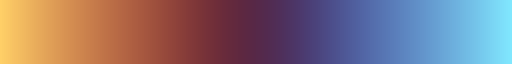

In [16]:
cmcrameri.cm.managua

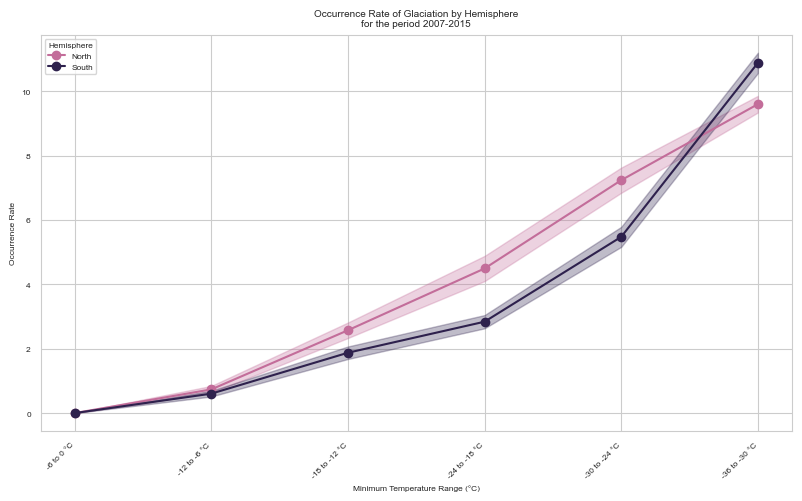

In [17]:
result_std = pole_temp_or.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_or.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2])#,cmap=cm.managua)
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title(f'Occurrence Rate of Glaciation by Hemisphere\nfor the period {min(years)}-{max(years)}')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


The glaciation occurance rate at each temperature range in the two hemispheres

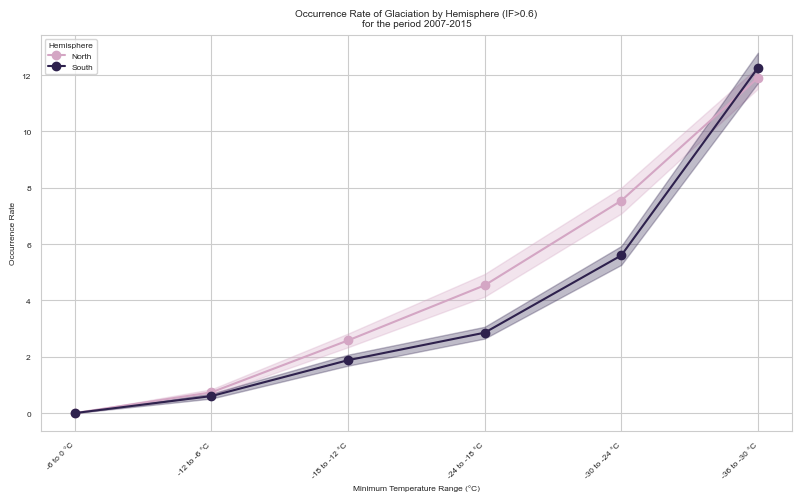

In [18]:
result_std = pole_temp_or_glac_possible.groupby(['min_temp',"Hemisphere"])['Occurance rate'].std()
result_mean = pole_temp_or_glac_possible.groupby(['min_temp',"Hemisphere"])['Occurance rate'].mean()

# Prepare DataFrame
df_mean = result_mean.reset_index().rename(columns={'Occurance rate': 'mean'})
df_std  = result_std .reset_index().rename(columns={'Occurance rate': 'std'})
df = pd.merge(df_mean, df_std, on=['min_temp', 'Hemisphere'])

# Compute range strings and midpoints
df['range_str'] = df['min_temp'].apply(lambda t: f"{t} to {t+6} °C")
df['midpoint']  = df['min_temp'] + 3  # midpoint of each 6° bin

# Establish the categorical ordering of ranges
order = (
    df[['midpoint', 'range_str']]
      .drop_duplicates()
      .sort_values('midpoint')         # from coldest (smallest min_temp) to warmest
)
midpoints = order['midpoint'].tolist()
labels     = order['range_str'].tolist()

# Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = plt.gca()
i=0
for hemisphere, grp in df.groupby('Hemisphere'):
    grp = grp.sort_values('midpoint')
    ax.plot(grp['midpoint'], grp['mean'], marker='o', label=hemisphere,color=classifiacation_palette[(i+1)%2*2])
    ax.fill_between(
        grp['midpoint'],
        grp['mean'] - grp['std'],
        grp['mean'] + grp['std'],
        color=classifiacation_palette[(i+1)%2*2],
        alpha=0.3
    )
    i+=1


# Tick at each midpoint, labeled by the range
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Invert so coldest (smallest midpoint) is on the right
ax.invert_xaxis()

ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
ax.set_title(f'Occurrence Rate of Glaciation by Hemisphere (IF>0.6)\nfor the period {min(years)}-{max(years)}')
ax.legend(title='Hemisphere')
plt.tight_layout()
plt.show()


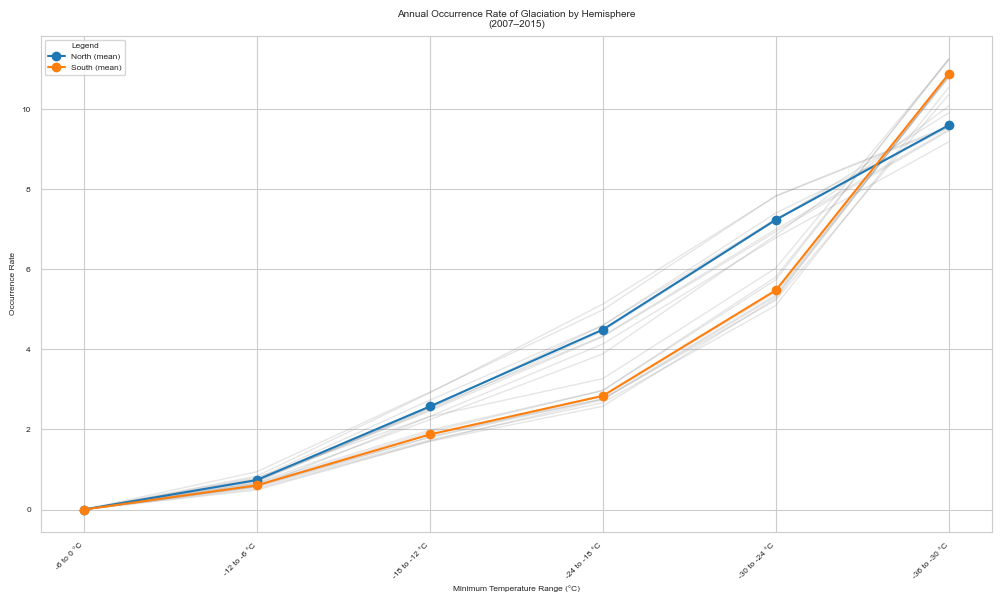

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming pole_temp_or is already defined in the environment

# Compute annual means by year, temperature bin, and hemisphere
annual = (
    pole_temp_or
    .groupby(['year', 'min_temp', 'Hemisphere'])['Occurance rate']
    .mean()
    .reset_index()
    .rename(columns={'Occurance rate': 'annual_rate'})
)
annual['midpoint'] = annual['min_temp'] + 3

# Compute aggregated mean across all years for reference
agg_mean = (
    pole_temp_or
    .groupby(['min_temp', 'Hemisphere'])['Occurance rate']
    .mean()
    .reset_index()
    .rename(columns={'Occurance rate': 'mean_rate'})
)
agg_mean['midpoint'] = agg_mean['min_temp'] + 3

# Prepare x-axis ticks and labels
order = (
    annual[['midpoint', 'min_temp']]
    .drop_duplicates()
    .sort_values('midpoint')
)
midpoints = order['midpoint'].tolist()
labels = [f"{t} to {t+6} °C" for t in order['min_temp']]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each year's curve in transparent gray
for hemi in annual['Hemisphere'].unique():
    hemi_data = annual[annual['Hemisphere'] == hemi]
    for yr in sorted(hemi_data['year'].unique()):
        year_data = hemi_data[hemi_data['year'] == yr].sort_values('midpoint')
        ax.plot(
            year_data['midpoint'],
            year_data['annual_rate'],
            color='gray',
            alpha=0.2,
            linewidth=1
        )

# Overlay aggregated mean curves
for hemi in agg_mean['Hemisphere'].unique():
    mean_data = agg_mean[agg_mean['Hemisphere'] == hemi].sort_values('midpoint')
    ax.plot(
        mean_data['midpoint'],
        mean_data['mean_rate'],
        marker='o',
        label=f"{hemi} (mean)"
    )

# Configure axes
ax.set_xticks(midpoints)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.invert_xaxis()  # Coldest on the right
ax.set_xlabel('Minimum Temperature Range (°C)')
ax.set_ylabel('Occurrence Rate')
years = sorted(pole_temp_or['year'].unique())
ax.set_title(f'Annual Occurrence Rate of Glaciation by Hemisphere\n({min(years)}–{max(years)})')
ax.legend(title='Legend')

plt.tight_layout()
plt.show()


In [20]:
pole_temp_season_or_glac_possible

,Unnamed: 0,Hemisphere,Season,min_temp,Occurance rate,year
0,0,North,DJF,-36,10.118556,2007
1,1,North,JJA,-36,15.446847,2007
2,2,North,MAM,-36,14.495766,2007
3,3,North,SON,-36,11.664822,2007
4,4,South,DJF,-36,16.011945,2007
...,...,...,...,...,...,...
427,427,North,SON,-6,0.000000,2015
428,428,South,DJF,-6,0.000000,2015
429,429,South,JJA,-6,0.000000,2015
430,430,South,MAM,-6,0.000000,2015


## Color palette testing

In [44]:
cmcrameri.cm.show_cmaps()

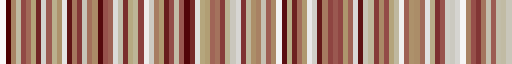

In [45]:
cmcrameri.cm.bilbaoS

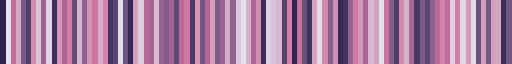

In [46]:
cmcrameri.cm.actonS

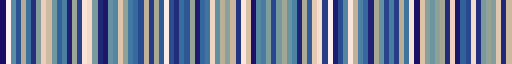

In [47]:
cmcrameri.cm.lapazS

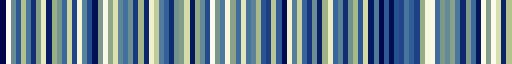

In [48]:
cmcrameri.cm.davosS

In [49]:
# classifiacation_palette = cmcrameri.cm.batlowS.colors[[3,4,2],:]
# classifiacation_palette = cmcrameri.cm.batlowWS.colors[1:4]
# classifiacation_palette = cmcrameri.cm.lapazS.colors[[0,2,3],:]
# classifiacation_palette = cmcrameri.cm.devonS.colors[[0,3,2],:]
# classifiacation_palette = cmcrameri.cm.davosS.colors[[0,3,2],:]
# classifiacation_palette = cmcrameri.cm.actonS.colors[[0,2,3],:]
# classifiacation_palette = cmcrameri.cm.bilbaoS.colors[[1,3,2],:]
classifiacation_palette

array([[0.180627, 0.129916, 0.300244],
       [0.763197, 0.428302, 0.605491],
       [0.829539, 0.652496, 0.769411]])